숙제 
<br>
2차원 공간 삼각형 ABC를 90도 회전시켰다가 돌려놓는것을 역행렬로 하는것을 수기로 풀기
<br>
3차원 공간 삼각형 ABC를 90도 회전시키는것을 수기로 풀기

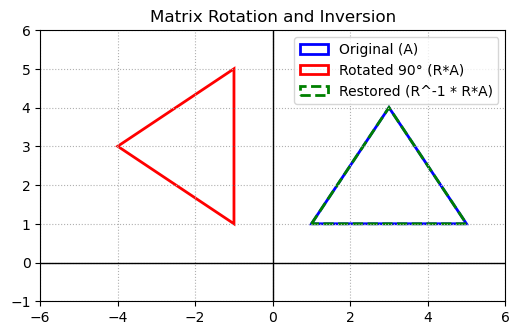

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. 초기 삼각형 좌표 (각 열이 하나의 점 [x, y]^T 가 되도록 전치하여 표현)
# vertices: [[1, 3, 5], [1, 4, 1]] 형태
vertices = np.array([[1, 3, 5], 
                    [1, 4, 1]])

# 2. 90도 회전 행렬 정의
R = np.array([[0, -1],
              [1, 0]])

# 3. 역행렬 (되돌리기) 정의
R_inv = np.linalg.inv(R)

# 4. 연산 수행
rotated = R @ vertices          # 90도 회전
restored = R_inv @ rotated      # 역행렬로 복구

# 시각화 함수
def draw_poly(coords, ax, label, color, linestyle='-'):
    # 다시 plot용 형식으로 변환 (N, 2)
    poly_coords = coords.T
    poly = patches.Polygon(poly_coords, closed=True, fill=False, 
                           edgecolor=color, linewidth=2, linestyle=linestyle, label=label)
    ax.add_patch(poly)

fig, ax = plt.subplots(figsize=(6, 6))

draw_poly(vertices, ax, 'Original (A)', 'blue')
draw_poly(rotated, ax, 'Rotated 90° (R*A)', 'red')
draw_poly(restored, ax, 'Restored (R^-1 * R*A)', 'green', linestyle='--')

# 축 설정
ax.set_xlim(-6, 6)
ax.set_ylim(-1, 6)
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.legend()
ax.grid(True, linestyle=':')
ax.set_aspect('equal') # 가로세로 비율 유지 (회전 확인을 위해 필수)

plt.title("Matrix Rotation and Inversion")
plt.show()

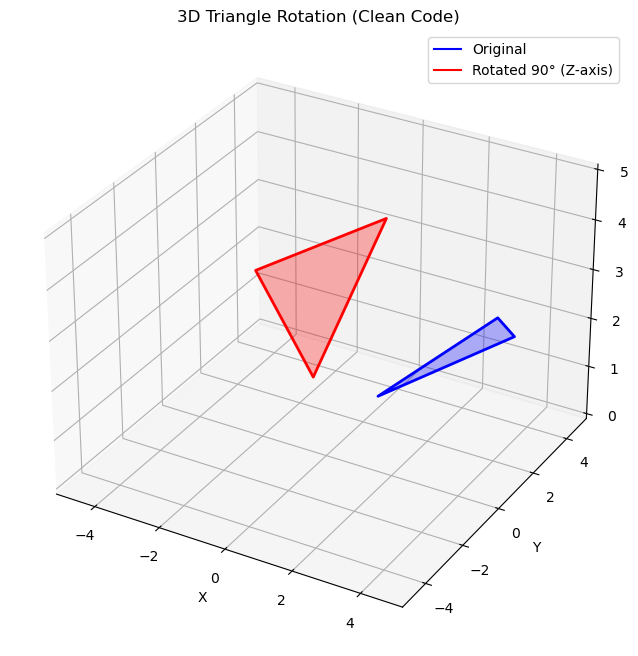

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. 초기 3차원 좌표
vertices = np.array([[1, 3, 5],
                    [1, 4, 1],
                    [1, 2, 3]])

# 2. Z축 기준 90도 회전 행렬
R_z = np.array([[0, -1, 0],
                [1, 0, 0],
                [0, 0, 1]])

# 3. 회전 연산
rotated_vertices = R_z @ vertices

# --- 수정된 부분: 축 생성 방식 변경 ---
# subplots에서 subplot_kw를 통해 3d 프로젝션을 바로 전달합니다.
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': '3d'})

def draw_triangle_3d(coords, ax, color, label):
    pts = coords.T
    tri = Poly3DCollection([pts], alpha=0.3, edgecolors=color, facecolors=color, linewidths=2)
    ax.add_collection3d(tri)
    ax.plot([], [], color=color, label=label)

# 삼각형 그리기
draw_triangle_3d(vertices, ax, 'blue', 'Original')
draw_triangle_3d(rotated_vertices, ax, 'red', 'Rotated 90° (Z-axis)')

# 축 설정
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(0, 5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.title("3D Triangle Rotation (Clean Code)")
plt.show()